# **KẾT NỐI DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **KẾT NỐI API KAGGEL**

In [ ]:
import os

# Thiết lập biến môi trường chứa API Token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_b61f3015360581afc0bb0c2bdde3bd0d"

# **TẢI DATASET**

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:31<00:00, 93.3MB/s]



# **TẠO THƯ MỤC**

In [ ]:
!mkdir -p /content/plantdisease_data

# **GIẢI NÉN**

In [ ]:
!unzip -q new-plant-diseases-dataset.zip -d /content/plantdisease_data/

# **LIỆT KÊ FILE, FOLDER TRONG FOLDER**

In [ ]:
!ls /content/plantdisease_data

'New Plant Diseases Dataset(Augmented)'   test


# **XÓA THƯ MỤC DƯ THỪA**

In [ ]:
import shutil

shutil.rmtree('/content/plantdisease_data/new plant diseases dataset(augmented)')

# **GÁN ĐƯỜNG DẪN VÀO BIẾN**

In [ ]:
import os

# Đường dẫn gốc dẫn thẳng tới thư mục train và valid
TRAIN_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VALID_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
TEST_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

print("Đường dẫn Train tồn tại không:", os.path.exists(TRAIN_DIR))
print("Đường dẫn Valid tồn tại không:", os.path.exists(VALID_DIR))
print("Đường dẫn Test tồn tại không:", os.path.exists(TEST_DIR))

Đường dẫn Train tồn tại không: True
Đường dẫn Valid tồn tại không: True
Đường dẫn Test tồn tại không: True


# **KIỂM TRA SỰ CÂN BẰNG GIỮA CÁC CLASS**


📊 PHÂN TÍCH CÂN BẰNG CLASS - TRAIN
Số lượng class: 38
Tổng số ảnh: 70,184
Số ảnh nhỏ nhất: 1642 ảnh
Số ảnh lớn nhất: 2022 ảnh
Số ảnh trung bình: 1846.9 ảnh
Số ảnh trung vị: 1841.0 ảnh
Độ lệch chuẩn: 105.5
Tỷ lệ mất cân bằng (Max/Min): 1.23x

📌 KẾT LUẬN:
✅ Dataset rất cân bằng


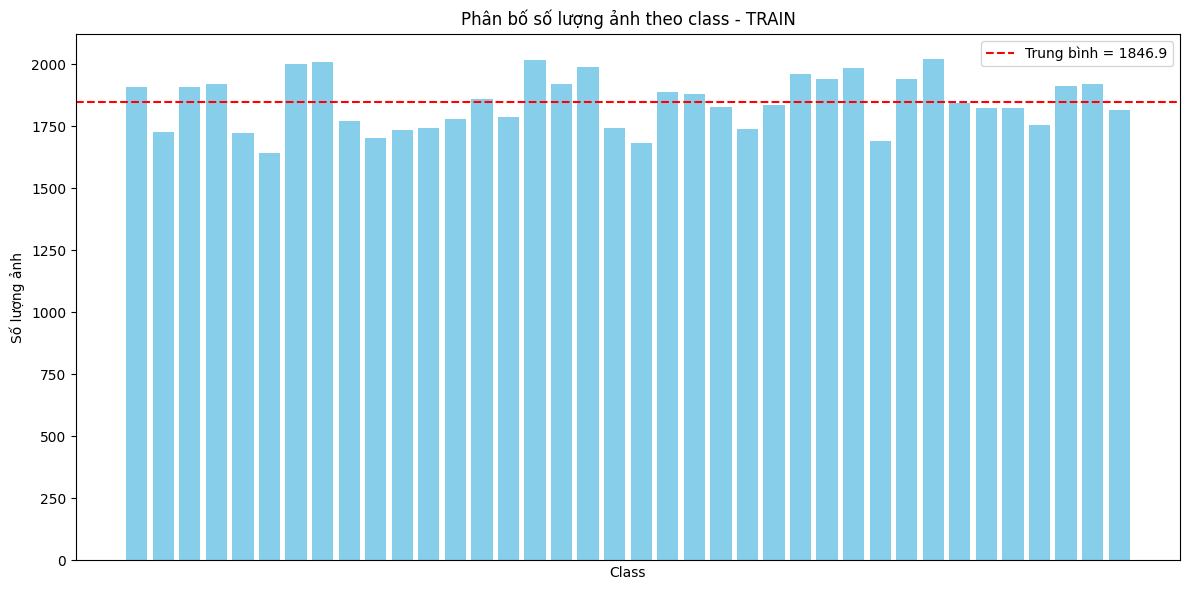


📊 PHÂN TÍCH CÂN BẰNG CLASS - VALID
Số lượng class: 38
Tổng số ảnh: 17,516
Số ảnh nhỏ nhất: 410 ảnh
Số ảnh lớn nhất: 505 ảnh
Số ảnh trung bình: 460.9 ảnh
Số ảnh trung vị: 459.5 ảnh
Độ lệch chuẩn: 26.9
Tỷ lệ mất cân bằng (Max/Min): 1.23x

📌 KẾT LUẬN:
✅ Dataset rất cân bằng


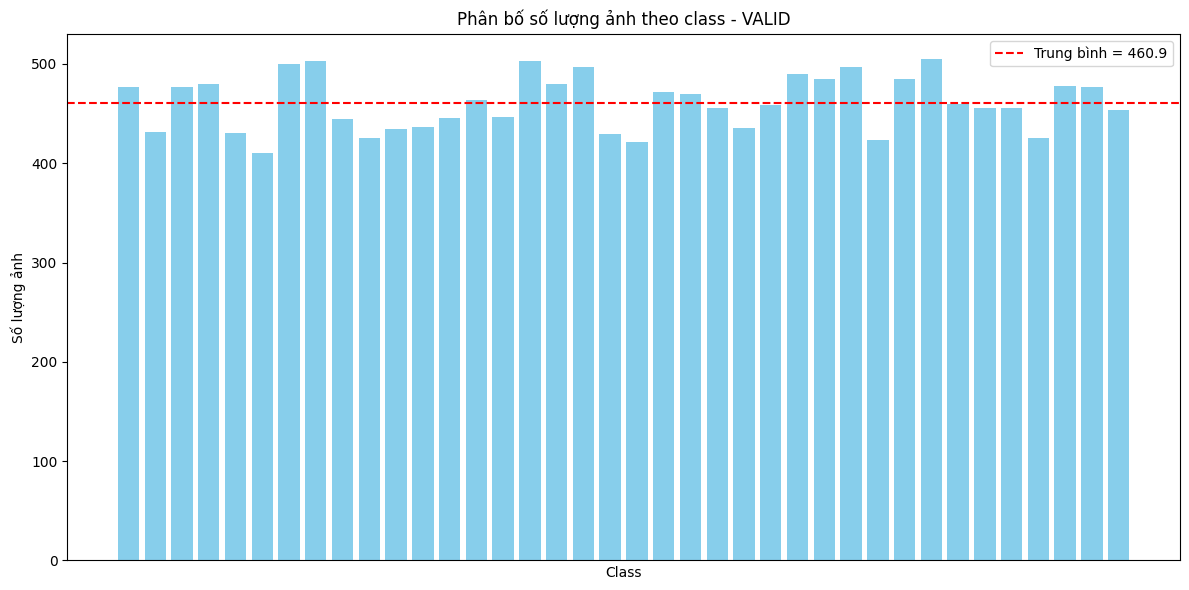


📊 PHÂN TÍCH CÂN BẰNG CLASS - TEST
Số lượng class: 38
Tổng số ảnh: 231
Số ảnh nhỏ nhất: 0 ảnh
Số ảnh lớn nhất: 84 ảnh
Số ảnh trung bình: 6.1 ảnh
Số ảnh trung vị: 0.0 ảnh
Độ lệch chuẩn: 20.8
Tỷ lệ mất cân bằng (Max/Min): infx

📌 KẾT LUẬN:
❌ Dataset mất cân bằng nặng
💡 Gợi ý: Nên sử dụng Data Augmentation mạnh cho các class ít ảnh


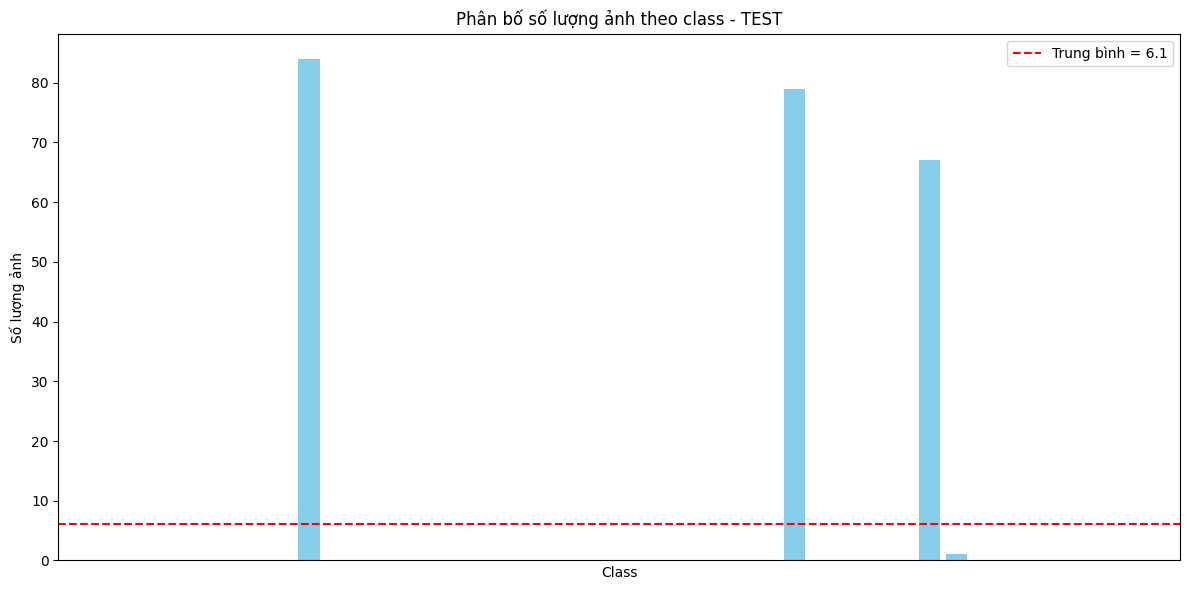

{'num_classes': 38,
 'total_images': 231,
 'min': 0,
 'max': 84,
 'mean': np.float64(6.078947368421052),
 'imbalance_ratio': inf,
 'class_counts': {'Corn_(maize)___Common_rust_': 0,
  'Peach___healthy': 0,
  'Corn_(maize)___Northern_Leaf_Blight': 0,
  'Tomato___Early_blight': 0,
  'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 0,
  'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 0,
  'Apple___healthy': 0,
  'Orange___Haunglongbing_(Citrus_greening)': 84,
  'Strawberry___Leaf_scorch': 0,
  'Tomato___Bacterial_spot': 0,
  'Squash___Powdery_mildew': 0,
  'Tomato___Septoria_leaf_spot': 0,
  'Raspberry___healthy': 0,
  'Corn_(maize)___healthy': 0,
  'Tomato___Tomato_mosaic_virus': 0,
  'Apple___Apple_scab': 0,
  'Grape___Esca_(Black_Measles)': 0,
  'Pepper,_bell___healthy': 0,
  'Apple___Cedar_apple_rust': 0,
  'Cherry_(including_sour)___Powdery_mildew': 0,
  'Grape___Black_rot': 0,
  'Tomato___Leaf_Mold': 0,
  'Tomato___Target_Spot': 0,
  'Tomato___Spider_mites Two-spotted_spider_mite

In [ ]:
import os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

def analyze_class_balance(data_dir, dataset_name="Dataset"):
    """
    Phân tích sự cân bằng giữa các class trong thư mục

    Args:
        data_dir (str): Đường dẫn đến thư mục train/valid/test
        dataset_name (str): Tên để hiển thị

    Returns:
        dict: Thông tin thống kê
    """
    if not os.path.exists(data_dir):
        print(f"❌ Thư mục {dataset_name} không tồn tại!")
        return None

    # Lấy danh sách các class và số lượng ảnh
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            class_counts[class_name] = num_images

    if not class_counts:
        print("Không tìm thấy class nào!")
        return None

    # Chuyển sang list để tính toán
    counts = list(class_counts.values())
    total_images = sum(counts)
    num_classes = len(counts)

    # Thống kê cơ bản
    min_count = min(counts)
    max_count = max(counts)
    mean_count = np.mean(counts)
    median_count = np.median(counts)
    std_count = np.std(counts)

    # Tính tỷ lệ mất cân bằng
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    # In báo cáo
    print(f"\n{'='*60}")
    print(f"📊 PHÂN TÍCH CÂN BẰNG CLASS - {dataset_name.upper()}")
    print(f"{'='*60}")
    print(f"Số lượng class: {num_classes}")
    print(f"Tổng số ảnh: {total_images:,}")
    print(f"Số ảnh nhỏ nhất: {min_count} ảnh")
    print(f"Số ảnh lớn nhất: {max_count} ảnh")
    print(f"Số ảnh trung bình: {mean_count:.1f} ảnh")
    print(f"Số ảnh trung vị: {median_count:.1f} ảnh")
    print(f"Độ lệch chuẩn: {std_count:.1f}")
    print(f"Tỷ lệ mất cân bằng (Max/Min): {imbalance_ratio:.2f}x")

    # Đánh giá mức độ mất cân bằng
    print(f"\n📌 KẾT LUẬN:")
    if imbalance_ratio <= 1.5:
        print("✅ Dataset rất cân bằng")
    elif imbalance_ratio <= 3.0:
        print("⚠️  Dataset hơi mất cân bằng (có thể chấp nhận được)")
    elif imbalance_ratio <= 5.0:
        print("⚠️  Dataset mất cân bằng trung bình")
    elif imbalance_ratio <= 10.0:
        print("❗ Dataset mất cân bằng khá nghiêm trọng")
    else:
        print("❌ Dataset mất cân bằng nặng")

    # Gợi ý
    if imbalance_ratio > 3.0:
        print("💡 Gợi ý: Nên sử dụng Data Augmentation mạnh cho các class ít ảnh")

    # Vẽ biểu đồ phân bố
    plt.figure(figsize=(12, 6))
    plt.bar(range(num_classes), counts, color='skyblue')
    plt.axhline(y=mean_count, color='red', linestyle='--', label=f'Trung bình = {mean_count:.1f}')
    plt.title(f'Phân bố số lượng ảnh theo class - {dataset_name}')
    plt.xlabel('Class')
    plt.ylabel('Số lượng ảnh')
    plt.legend()
    plt.xticks([])
    plt.tight_layout()
    plt.show()

    return {
        'num_classes': num_classes,
        'total_images': total_images,
        'min': min_count,
        'max': max_count,
        'mean': mean_count,
        'imbalance_ratio': imbalance_ratio,
        'class_counts': class_counts
    }


# ====================== CÁCH SỬ DỤNG ======================

# Đường dẫn (sửa theo đường dẫn của bạn)
BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Phân tích từng bộ
analyze_class_balance(TRAIN_DIR, "TRAIN")
analyze_class_balance(VALID_DIR, "VALID")
analyze_class_balance(TEST_DIR, "TEST")

In [ ]:
import os

TEST_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

print("⚠️ ĐANG XÓA TOÀN BỘ ẢNH TRONG TEST...")

count = 0

for class_name in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            file_path = os.path.join(class_path, file)

            try:
                os.remove(file_path)
                count += 1
            except Exception as e:
                print(f"Lỗi xóa {file_path}: {e}")

print(f"✅ Đã xóa {count} ảnh trong TEST")

⚠️ ĐANG XÓA TOÀN BỘ ẢNH TRONG TEST...
✅ Đã xóa 231 ảnh trong TEST


# **LẤY NGẪU NHIÊN 150 CỦA TỪNG CLASS ẢNH Ở DATASET 2 SANG TEST**

In [ ]:
import os
import random
import shutil

# ======================
# 📁 PATH
# ======================
color_dir = "/content/plantdisease_data2/plantvillage dataset/color"
test_dir = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

# ======================
# 🔐 SET LƯU ẢNH ĐÃ DÙNG
# ======================
used_images = set()

# ======================
# 🔥 LOOP TỪNG CLASS
# ======================
classes = sorted(os.listdir(color_dir))

for cls in classes:
    src_class_path = os.path.join(color_dir, cls)
    dst_class_path = os.path.join(test_dir, cls)

    if not os.path.isdir(src_class_path):
        continue

    os.makedirs(dst_class_path, exist_ok=True)

    # lấy tất cả ảnh
    all_images = [
        f for f in os.listdir(src_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(all_images)

    selected_count = 0

    for img_name in all_images:
        src_img = os.path.join(src_class_path, img_name)

        # 🔥 CHECK KHÔNG TRÙNG TOÀN BỘ DATASET
        if src_img in used_images:
            continue

        # copy sang test
        dst_img = os.path.join(dst_class_path, img_name)
        shutil.copy2(src_img, dst_img)

        used_images.add(src_img)
        selected_count += 1

        if selected_count >= 150:
            break

    print(f"{cls}: copied {selected_count} images (no duplicates)")

Apple___Apple_scab: copied 150 images (no duplicates)
Apple___Black_rot: copied 150 images (no duplicates)
Apple___Cedar_apple_rust: copied 150 images (no duplicates)
Apple___healthy: copied 150 images (no duplicates)
Blueberry___healthy: copied 150 images (no duplicates)
Cherry_(including_sour)___Powdery_mildew: copied 150 images (no duplicates)
Cherry_(including_sour)___healthy: copied 150 images (no duplicates)
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: copied 150 images (no duplicates)
Corn_(maize)___Common_rust_: copied 150 images (no duplicates)
Corn_(maize)___Northern_Leaf_Blight: copied 150 images (no duplicates)
Corn_(maize)___healthy: copied 150 images (no duplicates)
Grape___Black_rot: copied 150 images (no duplicates)
Grape___Esca_(Black_Measles): copied 150 images (no duplicates)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): copied 150 images (no duplicates)
Grape___healthy: copied 150 images (no duplicates)
Orange___Haunglongbing_(Citrus_greening): copied 150 image

In [ ]:
import os
import random
import shutil
from PIL import Image
import imagehash

# =====================================
# PATH
# =====================================
color_dir = "/content/plantdisease_data2/plantvillage dataset/color"

test_dir = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

# =====================================
# THAM SỐ
# =====================================
NUM_IMAGES_PER_CLASS = 150

# ngưỡng near-duplicate
# càng nhỏ càng nghiêm ngặt
HASH_THRESHOLD = 5

# =====================================
# GLOBAL HASH SET
# tránh trùng toàn dataset
# =====================================
global_hashes = []

# =====================================
# HÀM CHECK NEAR DUPLICATE
# =====================================
def is_near_duplicate(new_hash, hash_list, threshold=5):
    for h in hash_list:
        # khoảng cách Hamming
        if new_hash - h <= threshold:
            return True
    return False

# =====================================
# LOOP TỪNG CLASS
# =====================================
classes = sorted(os.listdir(color_dir))

for cls in classes:

    src_class_path = os.path.join(color_dir, cls)
    dst_class_path = os.path.join(test_dir, cls)

    if not os.path.isdir(src_class_path):
        continue

    os.makedirs(dst_class_path, exist_ok=True)

    # lấy toàn bộ ảnh
    all_images = [
        f for f in os.listdir(src_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(all_images)

    selected_count = 0
    skipped_duplicate = 0
    skipped_error = 0

    # hash riêng từng class
    class_hashes = []

    for img_name in all_images:

        if selected_count >= NUM_IMAGES_PER_CLASS:
            break

        src_img = os.path.join(src_class_path, img_name)

        try:
            # đọc ảnh
            img = Image.open(src_img).convert("RGB")

            # perceptual hash
            img_hash = imagehash.phash(img)

            # =====================================
            # CHECK DUPLICATE TRONG CLASS
            # =====================================
            if is_near_duplicate(
                img_hash,
                class_hashes,
                HASH_THRESHOLD
            ):
                skipped_duplicate += 1
                continue

            # =====================================
            # CHECK DUPLICATE TOÀN DATASET
            # =====================================
            if is_near_duplicate(
                img_hash,
                global_hashes,
                HASH_THRESHOLD
            ):
                skipped_duplicate += 1
                continue

            # =====================================
            # COPY ẢNH
            # =====================================
            dst_img = os.path.join(dst_class_path, img_name)

            shutil.copy2(src_img, dst_img)

            # lưu hash
            class_hashes.append(img_hash)
            global_hashes.append(img_hash)

            selected_count += 1

        except Exception as e:
            skipped_error += 1
            print(f"Error: {src_img}")
            print(e)

    print("=" * 60)
    print(f"CLASS: {cls}")
    print(f"Copied           : {selected_count}")
    print(f"Skipped duplicate: {skipped_duplicate}")
    print(f"Skipped errors   : {skipped_error}")

CLASS: Apple___Apple_scab
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Apple___Black_rot
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Apple___Cedar_apple_rust
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Apple___healthy
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Blueberry___healthy
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Cherry_(including_sour)___Powdery_mildew
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Cherry_(including_sour)___healthy
Copied           : 150
Skipped duplicate: 1
Skipped errors   : 0
CLASS: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Corn_(maize)___Common_rust_
Copied           : 150
Skipped duplicate: 0
Skipped errors   : 0
CLASS: Corn_(maize)___Northern_Leaf_Blight
Copied           : 150
Skipped duplicate: 0
Skipped error

# **TÌM VÀ XÓA ẢNH TRÙNG LẶP Ở DATASET 2**

In [ ]:
import os
import imagehash
from PIL import Image
from collections import defaultdict
import shutil

def find_and_remove_duplicates(train_dir, valid_dir, test_dir, threshold=5):
    """
    Kiểm tra và xóa ảnh trùng / near-duplicate giữa Train, Valid, Test
    threshold: Càng nhỏ càng nghiêm ngặt (0 = exact duplicate, 5-10 = near duplicate)
    """
    print("🔍 ĐANG QUÉT ẢNH TRÙNG VÀ NEAR-DUPLICATE...\n")

    hash_dict = defaultdict(list)  # hash -> list of (path, dataset_name)

    datasets = {
        'Train': train_dir,
        'Valid': valid_dir,
        'Test': test_dir
    }

    total_images = 0
    duplicates_found = 0

    for dataset_name, base_dir in datasets.items():
        if not os.path.exists(base_dir):
            print(f"❌ Thư mục {dataset_name} không tồn tại!")
            continue

        for class_name in sorted(os.listdir(base_dir)):
            class_path = os.path.join(base_dir, class_name)
            if not os.path.isdir(class_path):
                continue

            for img_file in os.listdir(class_path):
                if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(class_path, img_file)
                total_images += 1

                try:
                    with Image.open(img_path) as img:
                        # Sử dụng pHash (perceptual hash) - rất tốt cho near-duplicate
                        img_hash = str(imagehash.phash(img))
                        hash_dict[img_hash].append((img_path, dataset_name, class_name, img_file))
                except Exception as e:
                    print(f"Lỗi đọc ảnh {img_path}: {e}")

    # Tìm duplicates
    print(f"Đã quét {total_images:,} ảnh.")
    print(f"\n{'='*70}")
    print("📋 DANH SÁCH ẢNH TRÙNG / NEAR-DUPLICATE")
    print(f"{'='*70}")

    for h, paths in hash_dict.items():
        if len(paths) > 1:
            duplicates_found += len(paths) - 1
            print(f"\n🔄 Hash: {h} ({len(paths)} bản trùng)")

            for i, (path, ds, cls, fname) in enumerate(paths):
                print(f"   {i+1}. [{ds}] {cls}/{fname}")

            # Giữ lại ảnh đầu tiên (ưu tiên Train > Valid > Test)
            to_keep = paths[0][0]
            print(f"   → Giữ lại: {to_keep}")

            # Xóa các bản trùng còn lại
            for path, ds, cls, fname in paths[1:]:
                try:
                    os.remove(path)
                    print(f"   ❌ Đã xóa: {path}")
                except Exception as e:
                    print(f"   Lỗi xóa {path}: {e}")

    if duplicates_found == 0:
        print("\n✅ Không tìm thấy ảnh trùng hoặc near-duplicate nào!")
    else:
        print(f"\n✅ Hoàn thành! Đã xóa {duplicates_found} ảnh trùng / near-duplicate.")

    return duplicates_found


# ====================== CÁCH SỬ DỤNG ======================

BASE_DIR = "/content/plantdisease_data2/plantvillage dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "color")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Chạy chương trình
# threshold=0  -> chỉ exact duplicate
# threshold=5~8 -> near-duplicate (khuyến nghị)
duplicates = find_and_remove_duplicates(TRAIN_DIR, VALID_DIR, TEST_DIR, threshold=6)

🔍 ĐANG QUÉT ẢNH TRÙNG VÀ NEAR-DUPLICATE...

❌ Thư mục Valid không tồn tại!
❌ Thư mục Test không tồn tại!
Đã quét 54,305 ảnh.

📋 DANH SÁCH ẢNH TRÙNG / NEAR-DUPLICATE

🔄 Hash: ad6bd21cdb92c413 (2 bản trùng)
   1. [Train] Apple___healthy/acb21cc2-8d65-4880-a7bb-dcc1eab1564b___RS_HL 6272.JPG
   2. [Train] Apple___healthy/3d075f90-7002-4c45-abc0-4f35ee49aa79___RS_HL 6272.JPG
   → Giữ lại: /content/plantdisease_data2/plantvillage dataset/color/Apple___healthy/acb21cc2-8d65-4880-a7bb-dcc1eab1564b___RS_HL 6272.JPG
   ❌ Đã xóa: /content/plantdisease_data2/plantvillage dataset/color/Apple___healthy/3d075f90-7002-4c45-abc0-4f35ee49aa79___RS_HL 6272.JPG

🔄 Hash: f8808547d2f29abd (2 bản trùng)
   1. [Train] Apple___healthy/dc18b924-f172-445d-8fed-61445d437aaa___RS_HL 6270.JPG
   2. [Train] Apple___healthy/ced4e27a-5eff-4190-a33a-cdc3d84c811e___RS_HL 6270.JPG
   → Giữ lại: /content/plantdisease_data2/plantvillage dataset/color/Apple___healthy/dc18b924-f172-445d-8fed-61445d437aaa___RS_HL 6270.JPG
   

# **KIỂM TRA TÍNH NHẤT QUÁN GIỮA CÁC CLASS**

In [ ]:
import os

def check_class_consistency(train_dir, valid_dir, test_dir):
    """
    Kiểm tra xem các class giữa train, valid, test có giống nhau không
    """
    print("🔍 ĐANG KIỂM TRA TÍNH NHẤT QUÁN CỦA CÁC CLASS...\n")

    # Lấy danh sách class từ từng thư mục
    def get_classes(directory):
        if not os.path.exists(directory):
            print(f"❌ Thư mục không tồn tại: {directory}")
            return None
        classes = [cls for cls in os.listdir(directory)
                  if os.path.isdir(os.path.join(directory, cls))]
        return sorted(classes)  # Sắp xếp để so sánh thứ tự

    train_classes = get_classes(train_dir)
    valid_classes = get_classes(valid_dir)
    test_classes  = get_classes(test_dir)

    if None in [train_classes, valid_classes, test_classes]:
        return False

    # Kiểm tra số lượng class
    print(f"📊 Số class trong Train : {len(train_classes)}")
    print(f"📊 Số class trong Valid : {len(valid_classes)}")
    print(f"📊 Số class trong Test  : {len(test_classes)}")

    # So sánh tập class (không quan tâm thứ tự)
    set_train = set(train_classes)
    set_valid = set(valid_classes)
    set_test  = set(test_classes)

    all_same_set = (set_train == set_valid == set_test)

    print(f"\n{'='*60}")
    print("📋 KIỂM TRA CHI TIẾT")
    print(f"{'='*60}")

    if all_same_set:
        print("✅ Tất cả các class đều GIỐNG NHAU (về tên)")
    else:
        print("❌ Có sự khác biệt về tên class!")

        # Tìm class thừa/thiếu
        missing_in_valid = set_train - set_valid
        missing_in_test  = set_train - set_test
        extra_in_valid   = set_valid - set_train
        extra_in_test    = set_test - set_train

        if missing_in_valid:
            print(f"   • Thiếu trong Valid: {missing_in_valid}")
        if missing_in_test:
            print(f"   • Thiếu trong Test : {missing_in_test}")
        if extra_in_valid:
            print(f"   • Thừa trong Valid : {extra_in_valid}")
        if extra_in_test:
            print(f"   • Thừa trong Test  : {extra_in_test}")

    # Kiểm tra thứ tự (sau khi sorted)
    same_order = (train_classes == valid_classes == test_classes)

    print(f"\n📍 Kiểm tra thứ tự class:")
    if same_order:
        print("✅ Thứ tự class GIỐNG NHAU giữa Train - Valid - Test")
    else:
        print("⚠️  Thứ tự class KHÔNG giống nhau")
        print("   (Nhưng không sao nếu bạn dùng ImageDataGenerator hoặc tf.data)")

    # Hiển thị 5 class đầu tiên để kiểm tra
    print(f"\n🔍 5 class đầu tiên (sau khi sắp xếp):")
    for i in range(min(5, len(train_classes))):
        print(f"   {i+1:2d}. {train_classes[i]}")

    return all_same_set and same_order


# ====================== CÁCH SỬ DỤNG ======================

BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Chạy kiểm tra
check_class_consistency(TRAIN_DIR, VALID_DIR, TEST_DIR)

🔍 ĐANG KIỂM TRA TÍNH NHẤT QUÁN CỦA CÁC CLASS...

📊 Số class trong Train : 38
📊 Số class trong Valid : 38
📊 Số class trong Test  : 38

📋 KIỂM TRA CHI TIẾT
✅ Tất cả các class đều GIỐNG NHAU (về tên)

📍 Kiểm tra thứ tự class:
✅ Thứ tự class GIỐNG NHAU giữa Train - Valid - Test

🔍 5 class đầu tiên (sau khi sắp xếp):
    1. Apple___Apple_scab
    2. Apple___Black_rot
    3. Apple___Cedar_apple_rust
    4. Apple___healthy
    5. Blueberry___healthy


True

# **SỐ LƯỢNG CLASS VÀ ẢNH TRONG FOLDER TRAIN**

In [ ]:
import os

classes = sorted(os.listdir(TRAIN_DIR))

print(f"Tổng số lượng class tìm thấy: {len(classes)} classes")
print("-" * 50)

total_train_images = 0

for idx, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)

    num_images = len(os.listdir(class_path))
    total_train_images += num_images

    print(f"{idx+1}. Class: {class_name} -> Có {num_images} ảnh")

print("-" * 50)
print(f"Tổng số ảnh trong train: {total_train_images}")

Tổng số lượng class tìm thấy: 38 classes
--------------------------------------------------
1. Class: Apple___Apple_scab -> Có 2016 ảnh
2. Class: Apple___Black_rot -> Có 1987 ảnh
3. Class: Apple___Cedar_apple_rust -> Có 1760 ảnh
4. Class: Apple___healthy -> Có 2008 ảnh
5. Class: Blueberry___healthy -> Có 1816 ảnh
6. Class: Cherry_(including_sour)___Powdery_mildew -> Có 1683 ảnh
7. Class: Cherry_(including_sour)___healthy -> Có 1826 ảnh
8. Class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Có 1642 ảnh
9. Class: Corn_(maize)___Common_rust_ -> Có 1907 ảnh
10. Class: Corn_(maize)___Northern_Leaf_Blight -> Có 1908 ảnh
11. Class: Corn_(maize)___healthy -> Có 1859 ảnh
12. Class: Grape___Black_rot -> Có 1888 ảnh
13. Class: Grape___Esca_(Black_Measles) -> Có 1920 ảnh
14. Class: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) -> Có 1722 ảnh
15. Class: Grape___healthy -> Có 1692 ảnh
16. Class: Orange___Haunglongbing_(Citrus_greening) -> Có 2010 ảnh
17. Class: Peach___Bacterial_spot -> Có 183

# **SỐ LƯỢNG CLASS VÀ ẢNH TRONG FOLDER VALID**

In [ ]:
import os

classes = sorted(os.listdir(VALID_DIR))

print(f"Tổng số lượng class tìm thấy: {len(classes)} classes")
print("-" * 50)

total_valid_images = 0

for idx, class_name in enumerate(classes):
    class_path = os.path.join(VALID_DIR, class_name)

    num_images = len(os.listdir(class_path))
    total_valid_images += num_images

    print(f"{idx+1}. Class: {class_name} -> Có {num_images} ảnh")

print("-" * 50)
print(f"Tổng số ảnh trong valid: {total_valid_images}")

Tổng số lượng class tìm thấy: 38 classes
--------------------------------------------------
1. Class: Apple___Apple_scab -> Có 504 ảnh
2. Class: Apple___Black_rot -> Có 497 ảnh
3. Class: Apple___Cedar_apple_rust -> Có 440 ảnh
4. Class: Apple___healthy -> Có 502 ảnh
5. Class: Blueberry___healthy -> Có 454 ảnh
6. Class: Cherry_(including_sour)___Powdery_mildew -> Có 421 ảnh
7. Class: Cherry_(including_sour)___healthy -> Có 456 ảnh
8. Class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Có 410 ảnh
9. Class: Corn_(maize)___Common_rust_ -> Có 477 ảnh
10. Class: Corn_(maize)___Northern_Leaf_Blight -> Có 477 ảnh
11. Class: Corn_(maize)___healthy -> Có 465 ảnh
12. Class: Grape___Black_rot -> Có 472 ảnh
13. Class: Grape___Esca_(Black_Measles) -> Có 480 ảnh
14. Class: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) -> Có 430 ảnh
15. Class: Grape___healthy -> Có 423 ảnh
16. Class: Orange___Haunglongbing_(Citrus_greening) -> Có 503 ảnh
17. Class: Peach___Bacterial_spot -> Có 459 ảnh
18. Class: 

# **SỐ LƯỢNG CLASS VÀ ẢNH TRONG FOLDER TEST**

In [ ]:
import os

# Lấy tất cả item trong TEST_DIR
items = os.listdir(TEST_DIR)

# Kiểm tra xem có thư mục class hay không
class_dirs = [
    item for item in items
    if os.path.isdir(os.path.join(TEST_DIR, item))
]

print("-" * 50)

# Nếu có class
if len(class_dirs) > 0:
    print(f"Tổng số lượng class tìm thấy: {len(class_dirs)} classes")
    print("-" * 50)

    total_images = 0

    for idx, class_name in enumerate(sorted(class_dirs)):
        class_path = os.path.join(TEST_DIR, class_name)

        num_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        total_images += num_images

        print(f"{idx+1}. Class: {class_name} -> Có {num_images} ảnh")

    print("-" * 50)
    print(f"Tổng số ảnh trong test: {total_images}")

# Nếu không có class, chỉ có ảnh
else:
    test_images = [
        f for f in items
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    print("Thư mục test không có class.")
    print(f"Tổng số ảnh trong test: {len(test_images)}")

print("-" * 50)

--------------------------------------------------
Tổng số lượng class tìm thấy: 38 classes
--------------------------------------------------
1. Class: Apple___Apple_scab -> Có 0 ảnh
2. Class: Apple___Black_rot -> Có 0 ảnh
3. Class: Apple___Cedar_apple_rust -> Có 0 ảnh
4. Class: Apple___healthy -> Có 0 ảnh
5. Class: Blueberry___healthy -> Có 0 ảnh
6. Class: Cherry_(including_sour)___Powdery_mildew -> Có 0 ảnh
7. Class: Cherry_(including_sour)___healthy -> Có 0 ảnh
8. Class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Có 0 ảnh
9. Class: Corn_(maize)___Common_rust_ -> Có 0 ảnh
10. Class: Corn_(maize)___Northern_Leaf_Blight -> Có 0 ảnh
11. Class: Corn_(maize)___healthy -> Có 0 ảnh
12. Class: Grape___Black_rot -> Có 0 ảnh
13. Class: Grape___Esca_(Black_Measles) -> Có 0 ảnh
14. Class: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) -> Có 0 ảnh
15. Class: Grape___healthy -> Có 0 ảnh
16. Class: Orange___Haunglongbing_(Citrus_greening) -> Có 84 ảnh
17. Class: Peach___Bacterial_spot -> Có

# **THỐNG KÊ SỐ LƯỢNG ẢNH VÀ TÍNH TOÁN TỶ LỆ PHÂN CHIA**

In [ ]:
import os

# =========================
# ĐƯỜNG DẪN DATASET
# =========================
TRAIN_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

VALID_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

TEST_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"


# =========================
# HÀM ĐẾM ẢNH
# =========================
def count_images(folder):
    total = 0

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((
                ".jpg",
                ".jpeg",
                ".png"
            )):
                total += 1

    return total


# =========================
# ĐẾM SỐ ẢNH
# =========================
train_count = count_images(TRAIN_DIR)
valid_count = count_images(VALID_DIR)
test_count = count_images(TEST_DIR)

# Tổng
total_images = train_count + valid_count + test_count


# =========================
# TÍNH PHẦN TRĂM
# =========================
train_percent = (train_count / total_images) * 100
valid_percent = (valid_count / total_images) * 100
test_percent = (test_count / total_images) * 100


# =========================
# IN KẾT QUẢ
# =========================
print("===== THỐNG KÊ DATASET =====")

print(f"Train images : {train_count}")
print(f"Valid images : {valid_count}")
print(f"Test images  : {test_count}")

print("\n===== PHẦN TRĂM =====")

print(f"Train : {train_percent:.2f}%")
print(f"Valid : {valid_percent:.2f}%")
print(f"Test  : {test_percent:.2f}%")

===== THỐNG KÊ DATASET =====
Train images : 70295
Valid images : 17572
Test images  : 5700

===== PHẦN TRĂM =====
Train : 75.13%
Valid : 18.78%
Test  : 6.09%


In [ ]:
import os

def analyze_dataset_split(train_dir, valid_dir, test_dir):
    """
    Thống kê số lượng ảnh và tỷ lệ phân chia giữa train, valid, test
    """
    print("📊 ĐANG THỐNG KÊ PHÂN BỐ DATASET...\n")

    def count_images(directory):
        if not os.path.exists(directory):
            print(f"❌ Thư mục không tồn tại: {directory}")
            return 0

        total = 0
        class_counts = {}

        for class_name in os.listdir(directory):
            class_path = os.path.join(directory, class_name)
            if os.path.isdir(class_path):
                # Đếm file ảnh
                images = [f for f in os.listdir(class_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'))]
                count = len(images)
                total += count
                class_counts[class_name] = count

        return total, class_counts

    # Đếm số ảnh từng bộ
    train_count, _ = count_images(train_dir)
    valid_count, _ = count_images(valid_dir)
    test_count,  _ = count_images(test_dir)

    total_images = train_count + valid_count + test_count

    # Tính tỷ lệ phần trăm
    if total_images > 0:
        train_pct = (train_count / total_images) * 100
        valid_pct = (valid_count / total_images) * 100
        test_pct  = (test_count / total_images) * 100
    else:
        train_pct = valid_pct = test_pct = 0

    # In báo cáo
    print(f"{'='*65}")
    print(f"📈 THỐNG KÊ PHÂN BỐ DATASET")
    print(f"{'='*65}")
    print(f"{'Train':<12}: {train_count:>8,} ảnh  ({train_pct:6.2f}%)")
    print(f"{'Valid':<12}: {valid_count:>8,} ảnh  ({valid_pct:6.2f}%)")
    print(f"{'Test':<12}: {test_count:>8,} ảnh  ({test_pct:6.2f}%)")
    print(f"{'-'*65}")
    print(f"{'TỔNG CỘNG':<12}: {total_images:>8,} ảnh  (100.00%)")

    # Đánh giá tỷ lệ phân chia
    print(f"\n📌 ĐÁNH GIÁ:")
    if abs(train_pct - 70) < 5 and abs(valid_pct - 20) < 5 and abs(test_pct - 10) < 5:
        print("✅ Tỷ lệ phân chia rất tốt (gần với 70/20/10)")
    elif abs(train_pct - 80) < 10 and abs(valid_pct - 15) < 8 and abs(test_pct - 5) < 5:
        print("✅ Tỷ lệ phân chia tốt (gần với 80/15/5)")
    else:
        print("⚠️  Tỷ lệ phân chia chưa chuẩn (nên khoảng 70-80% Train)")

    # Gợi ý
    if test_count == 0:
        print("❗ Chưa có dữ liệu Test - Nên bổ sung một ít ảnh vào test")
    elif test_count < 100:
        print(f"⚠️  Số ảnh test khá ít ({test_count} ảnh)")

    return {
        'train': train_count,
        'valid': valid_count,
        'test': test_count,
        'total': total_images,
        'train_pct': train_pct,
        'valid_pct': valid_pct,
        'test_pct': test_pct
    }


# ====================== CÁCH SỬ DỤNG ======================

BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Chạy chương trình
stats = analyze_dataset_split(TRAIN_DIR, VALID_DIR, TEST_DIR)

📊 ĐANG THỐNG KÊ PHÂN BỐ DATASET...

📈 THỐNG KÊ PHÂN BỐ DATASET
Train       :   70,184 ảnh  ( 75.14%)
Valid       :   17,516 ảnh  ( 18.75%)
Test        :    5,700 ảnh  (  6.10%)
-----------------------------------------------------------------
TỔNG CỘNG   :   93,400 ảnh  (100.00%)

📌 ĐÁNH GIÁ:
✅ Tỷ lệ phân chia tốt (gần với 80/15/5)


# **TẠO NHANH CLASS TRONG TEST (ĐỪNG BẬN TÂM)**

In [ ]:
import os

# ====================== CÀI ĐẶT ĐƯỜNG DẪN ======================
BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

# ============================================================

print("Đang kiểm tra đường dẫn...")
print("Train tồn tại:", os.path.exists(TRAIN_DIR))
print("Test tồn tại:", os.path.exists(TEST_DIR))

# Lấy danh sách class từ train
classes = [cls for cls in os.listdir(TRAIN_DIR)
           if os.path.isdir(os.path.join(TRAIN_DIR, cls))]

print(f"\nTìm thấy {len(classes)} classes trong train.")
print("Đang tạo thư mục class trong test (không copy ảnh)...\n")

# Tạo thư mục
created = 0
for cls in sorted(classes):   # sắp xếp cho dễ nhìn
    class_path = os.path.join(TEST_DIR, cls)
    if not os.path.exists(class_path):
        os.makedirs(class_path)
        created += 1
        print(f"✓ Đã tạo: {cls}")
    else:
        print(f"→ Đã tồn tại: {cls}")

print(f"\n=== HOÀN THÀNH ===")
print(f"Đã tạo thêm {created} thư mục class trong test.")
print(f"Tổng số class trong test hiện tại: {len(os.listdir(TEST_DIR))}")

Đang kiểm tra đường dẫn...
Train tồn tại: True
Test tồn tại: False

Tìm thấy 38 classes trong train.
Đang tạo thư mục class trong test (không copy ảnh)...

✓ Đã tạo: Apple___Apple_scab
✓ Đã tạo: Apple___Black_rot
✓ Đã tạo: Apple___Cedar_apple_rust
✓ Đã tạo: Apple___healthy
✓ Đã tạo: Blueberry___healthy
✓ Đã tạo: Cherry_(including_sour)___Powdery_mildew
✓ Đã tạo: Cherry_(including_sour)___healthy
✓ Đã tạo: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
✓ Đã tạo: Corn_(maize)___Common_rust_
✓ Đã tạo: Corn_(maize)___Northern_Leaf_Blight
✓ Đã tạo: Corn_(maize)___healthy
✓ Đã tạo: Grape___Black_rot
✓ Đã tạo: Grape___Esca_(Black_Measles)
✓ Đã tạo: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
✓ Đã tạo: Grape___healthy
✓ Đã tạo: Orange___Haunglongbing_(Citrus_greening)
✓ Đã tạo: Peach___Bacterial_spot
✓ Đã tạo: Peach___healthy
✓ Đã tạo: Pepper,_bell___Bacterial_spot
✓ Đã tạo: Pepper,_bell___healthy
✓ Đã tạo: Potato___Early_blight
✓ Đã tạo: Potato___Late_blight
✓ Đã tạo: Potato___healthy
✓ Đã

# **XEM ẢNH NGẪU NHIÊN**

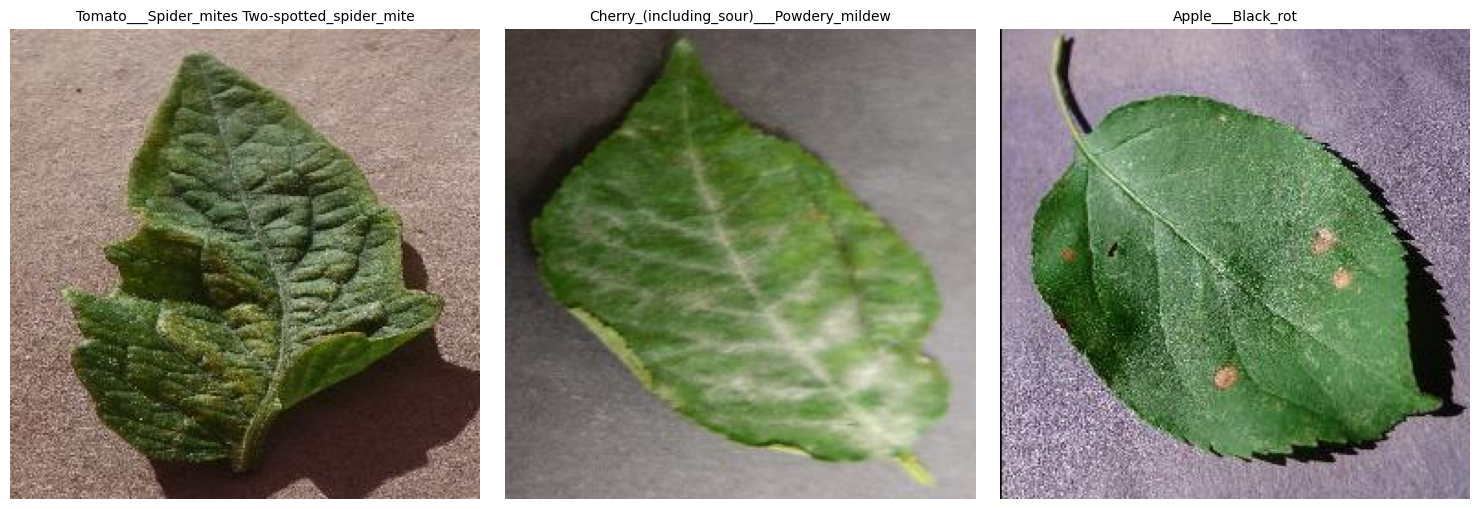

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Chọn ngẫu nhiên 3 class bất kỳ để xem thử
random_classes = random.sample(classes, 3)

# Cấu hình khung hiển thị 3 ảnh nằm ngang
plt.figure(figsize=(15, 5))

for i, class_name in enumerate(random_classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    # Lấy ngẫu nhiên 1 bức ảnh trong class đó
    random_image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, random_image_name)

    # Mở ảnh bằng thư viện PIL
    img = Image.open(image_path)

    # Vẽ ảnh lên màn hình bằng Matplotlib
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis('off') # Ẩn trục tọa độ x, y đi cho đẹp

plt.tight_layout()
plt.show()

# **KIỂM TRA CÁC THÔNG TIN CỦA ẢNH TRONG CLASS**

In [ ]:
import os
from PIL import Image
import numpy as np
from collections import defaultdict
import pandas as pd

def analyze_images_info(data_dir, dataset_name="Dataset", num_samples=5):
    """
    Kiểm tra thông tin chi tiết của các ảnh trong dataset
    """
    print(f"🔍 ĐANG PHÂN TÍCH THÔNG TIN ẢNH - {dataset_name.upper()}\n")

    if not os.path.exists(data_dir):
        print(f"❌ Thư mục không tồn tại: {data_dir}")
        return None

    image_stats = defaultdict(list)
    corrupted = []
    class_info = {}

    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'))]

        if not images:
            continue

        class_info[class_name] = len(images)

        print(f"📁 Class: {class_name} ({len(images)} ảnh)")

        # Kiểm tra một số ảnh mẫu
        sizes = []
        modes = []
        file_sizes = []

        for img_file in images[:num_samples]:  # Kiểm tra num_samples ảnh đầu tiên
            img_path = os.path.join(class_path, img_file)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    mode = img.mode
                    file_size = os.path.getsize(img_path) / (1024)  # KB

                    sizes.append((width, height))
                    modes.append(mode)
                    file_sizes.append(file_size)

                    image_stats['width'].append(width)
                    image_stats['height'].append(height)
                    image_stats['mode'].append(mode)
                    image_stats['class'].append(class_name)

            except Exception as e:
                corrupted.append((class_name, img_file, str(e)))
                print(f"   ❌ Ảnh hỏng: {img_file}")

        # Thống kê nhanh cho class
        if sizes:
            avg_width = np.mean([s[0] for s in sizes])
            avg_height = np.mean([s[1] for s in sizes])
            print(f"   → Kích thước trung bình: {avg_width:.0f} x {avg_height:.0f}")
            print(f"   → Mode phổ biến: {max(set(modes), key=modes.count)}")
            print(f"   → Dung lượng trung bình: {np.mean(file_sizes):.1f} KB")

    # Tổng kết toàn dataset
    total_images = sum(class_info.values())

    print(f"\n{'='*70}")
    print(f"📊 TỔNG KẾT THÔNG TIN ẢNH - {dataset_name.upper()}")
    print(f"{'='*70}")
    print(f"Tổng số class: {len(class_info)}")
    print(f"Tổng số ảnh: {total_images:,}")

    if image_stats['width']:
        print(f"Kích thước trung bình: {np.mean(image_stats['width']):.0f} x {np.mean(image_stats['height']):.0f}")
        print(f"Mode ảnh phổ biến: {max(set(image_stats['mode']), key=image_stats['mode'].count)}")

    if corrupted:
        print(f"\n⚠️  Số ảnh bị hỏng: {len(corrupted)}")
        for c in corrupted[:5]:
            print(f"   - {c[0]}/{c[1]}")
    else:
        print("\n✅ Không phát hiện ảnh bị hỏng")

    # Tạo bảng thống kê số lượng ảnh theo class
    df = pd.DataFrame({
        'Class': list(class_info.keys()),
        'Số lượng ảnh': list(class_info.values())
    })
    df = df.sort_values('Số lượng ảnh', ascending=False)

    print(f"\n📋 Top 5 class có nhiều ảnh nhất:")
    print(df.head().to_string(index=False))

    return df, corrupted


# ====================== CÁCH SỬ DỤNG ======================

BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Phân tích từng bộ
print("=== PHÂN TÍCH TRAIN ===")
train_df, train_corrupted = analyze_images_info(TRAIN_DIR, "TRAIN", num_samples=3)

print("\n=== PHÂN TÍCH VALID ===")
valid_df, valid_corrupted = analyze_images_info(VALID_DIR, "VALID", num_samples=3)

print("\n=== PHÂN TÍCH TEST ===")
test_df, test_corrupted = analyze_images_info(TEST_DIR, "TEST", num_samples=3)

=== PHÂN TÍCH TRAIN ===
🔍 ĐANG PHÂN TÍCH THÔNG TIN ẢNH - TRAIN

📁 Class: Apple___Apple_scab (2016 ảnh)
   → Kích thước trung bình: 256 x 256
   → Mode phổ biến: RGB
   → Dung lượng trung bình: 13.5 KB
📁 Class: Apple___Black_rot (1987 ảnh)
   → Kích thước trung bình: 256 x 256
   → Mode phổ biến: RGB
   → Dung lượng trung bình: 19.5 KB
📁 Class: Apple___Cedar_apple_rust (1743 ảnh)
   → Kích thước trung bình: 256 x 256
   → Mode phổ biến: RGB
   → Dung lượng trung bình: 10.8 KB
📁 Class: Apple___healthy (2000 ảnh)
   → Kích thước trung bình: 256 x 256
   → Mode phổ biến: RGB
   → Dung lượng trung bình: 11.7 KB
📁 Class: Blueberry___healthy (1816 ảnh)
   → Kích thước trung bình: 256 x 256
   → Mode phổ biến: RGB
   → Dung lượng trung bình: 16.5 KB
📁 Class: Cherry_(including_sour)___Powdery_mildew (1683 ảnh)
   → Kích thước trung bình: 256 x 256
   → Mode phổ biến: RGB
   → Dung lượng trung bình: 11.4 KB
📁 Class: Cherry_(including_sour)___healthy (1826 ảnh)
   → Kích thước trung bình: 256 x 2

# **BIỂU ĐỒ KÍCH THƯỚC ẢNH**

📏 ĐANG PHÂN TÍCH KÍCH THƯỚC ẢNH - VALID

Đã kiểm tra 17,572 ảnh
Kích thước trung bình : 256 x 256 pixels
Kích thước nhỏ nhất  : 256 x 256
Kích thước lớn nhất   : 256 x 256


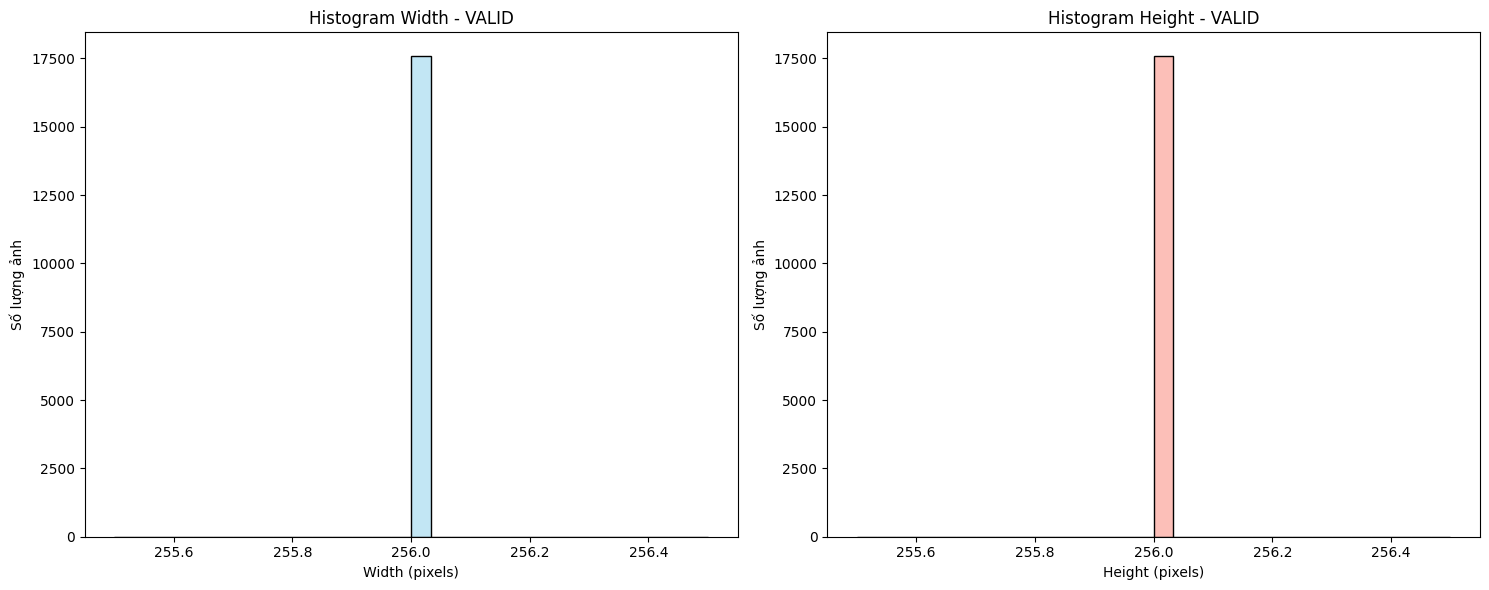

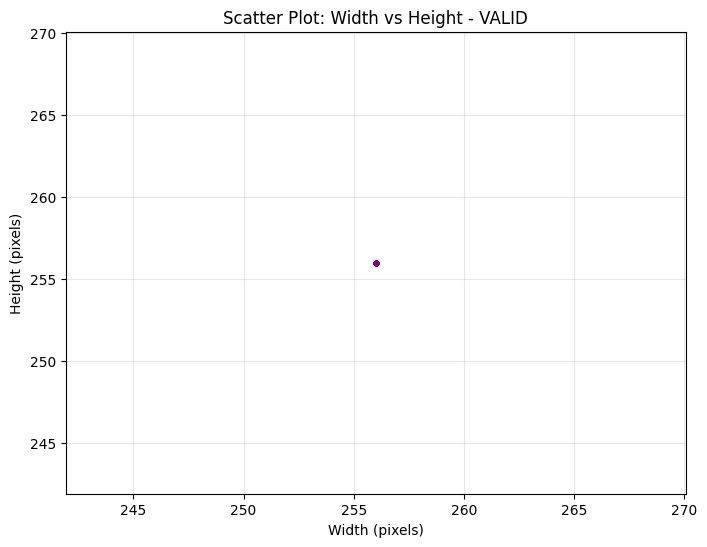

📏 ĐANG PHÂN TÍCH KÍCH THƯỚC ẢNH - TEST

Đã kiểm tra 5,700 ảnh
Kích thước trung bình : 256 x 256 pixels
Kích thước nhỏ nhất  : 256 x 256
Kích thước lớn nhất   : 256 x 256


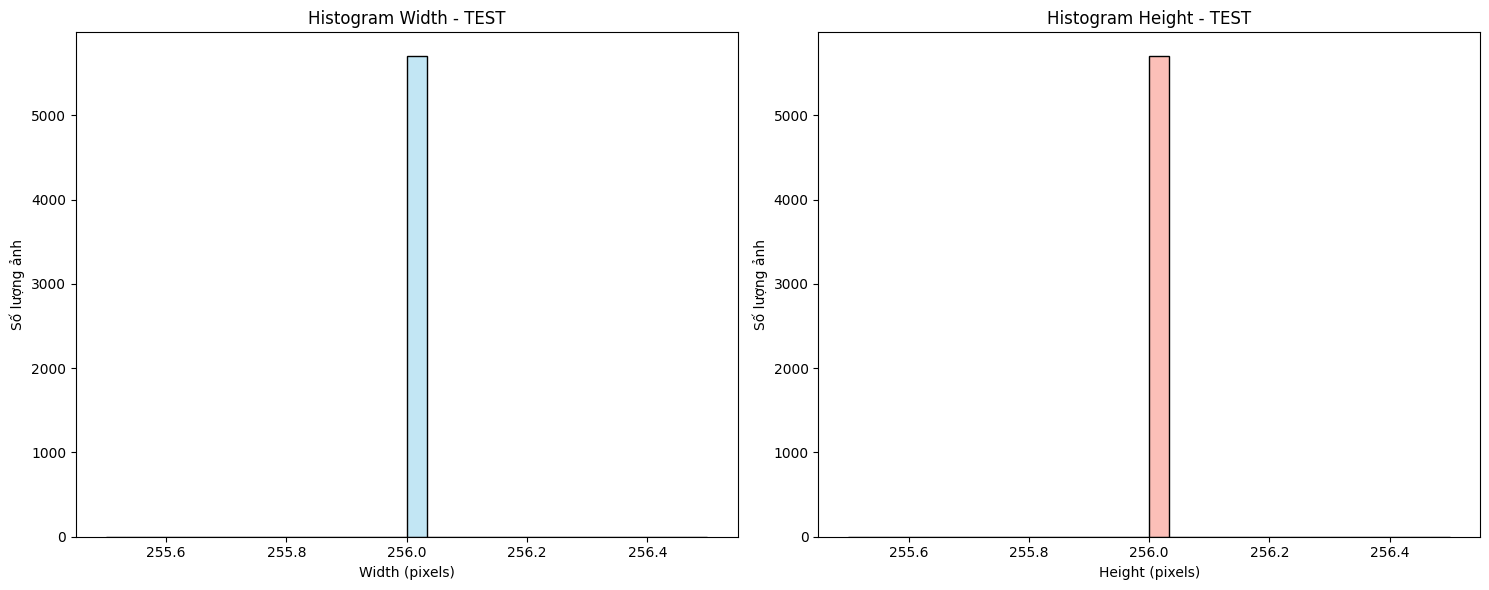

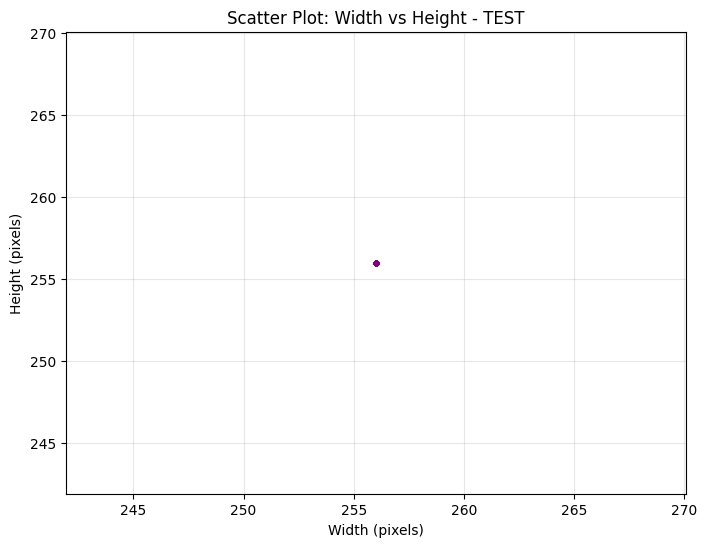

In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_image_size_histogram(data_dir, dataset_name="Dataset", max_samples=2000):
    """
    Hiển thị histogram kích thước (width & height) của các ảnh
    """
    print(f"📏 ĐANG PHÂN TÍCH KÍCH THƯỚC ẢNH - {dataset_name.upper()}\n")

    if not os.path.exists(data_dir):
        print(f"❌ Thư mục không tồn tại: {data_dir}")
        return

    widths = []
    heights = []
    total_checked = 0

    # Duyệt qua tất cả class
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'))]

        # Giới hạn số lượng ảnh để tránh quá chậm
        for img_file in image_files[:max_samples]:
            img_path = os.path.join(class_path, img_file)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    total_checked += 1
            except:
                continue  # Bỏ qua ảnh lỗi

    if not widths:
        print("Không tìm thấy ảnh nào!")
        return

    # Thống kê
    print(f"Đã kiểm tra {total_checked:,} ảnh")
    print(f"Kích thước trung bình : {np.mean(widths):.0f} x {np.mean(heights):.0f} pixels")
    print(f"Kích thước nhỏ nhất  : {min(widths)} x {min(heights)}")
    print(f"Kích thước lớn nhất   : {max(widths)} x {max(heights)}")

    # Vẽ histogram
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Histogram Width
    sns.histplot(widths, bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram Width - {dataset_name}')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Số lượng ảnh')

    # Histogram Height
    sns.histplot(heights, bins=30, kde=True, ax=axes[1], color='salmon')
    axes[1].set_title(f'Histogram Height - {dataset_name}')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Số lượng ảnh')

    plt.tight_layout()
    plt.show()

    # Scatter plot Width vs Height
    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, alpha=0.5, s=10, color='purple')
    plt.title(f'Scatter Plot: Width vs Height - {dataset_name}')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Height (pixels)')
    plt.grid(True, alpha=0.3)
    plt.show()


# ====================== CÁCH SỬ DỤNG ======================

BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Chọn phân tích
# print("=== Histogram Kích Thước Ảnh - TRAIN ===")
# plot_image_size_histogram(TRAIN_DIR, "TRAIN")

# Nếu muốn phân tích cả 3 bộ, uncomment các dòng dưới:
plot_image_size_histogram(VALID_DIR, "VALID")
plot_image_size_histogram(TEST_DIR, "TEST")

# **LOẠI BỎ ẢNH TRÙNG**

In [ ]:
!pip install pillow imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.2 MB/s eta 0:00:00


In [ ]:
import os
import imagehash
from PIL import Image
from collections import defaultdict
import shutil

def find_and_remove_duplicates(train_dir, valid_dir, test_dir, threshold=5):
    """
    Kiểm tra và xóa ảnh trùng / near-duplicate giữa Train, Valid, Test
    threshold: Càng nhỏ càng nghiêm ngặt (0 = exact duplicate, 5-10 = near duplicate)
    """
    print("🔍 ĐANG QUÉT ẢNH TRÙNG VÀ NEAR-DUPLICATE...\n")

    hash_dict = defaultdict(list)  # hash -> list of (path, dataset_name)

    datasets = {
        'Train': train_dir,
        'Valid': valid_dir,
        'Test': test_dir
    }

    total_images = 0
    duplicates_found = 0

    for dataset_name, base_dir in datasets.items():
        if not os.path.exists(base_dir):
            print(f"❌ Thư mục {dataset_name} không tồn tại!")
            continue

        for class_name in sorted(os.listdir(base_dir)):
            class_path = os.path.join(base_dir, class_name)
            if not os.path.isdir(class_path):
                continue

            for img_file in os.listdir(class_path):
                if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(class_path, img_file)
                total_images += 1

                try:
                    with Image.open(img_path) as img:
                        # Sử dụng pHash (perceptual hash) - rất tốt cho near-duplicate
                        img_hash = str(imagehash.phash(img))
                        hash_dict[img_hash].append((img_path, dataset_name, class_name, img_file))
                except Exception as e:
                    print(f"Lỗi đọc ảnh {img_path}: {e}")

    # Tìm duplicates
    print(f"Đã quét {total_images:,} ảnh.")
    print(f"\n{'='*70}")
    print("📋 DANH SÁCH ẢNH TRÙNG / NEAR-DUPLICATE")
    print(f"{'='*70}")

    for h, paths in hash_dict.items():
        if len(paths) > 1:
            duplicates_found += len(paths) - 1
            print(f"\n🔄 Hash: {h} ({len(paths)} bản trùng)")

            for i, (path, ds, cls, fname) in enumerate(paths):
                print(f"   {i+1}. [{ds}] {cls}/{fname}")

            # Giữ lại ảnh đầu tiên (ưu tiên Train > Valid > Test)
            to_keep = paths[0][0]
            print(f"   → Giữ lại: {to_keep}")

            # Xóa các bản trùng còn lại
            for path, ds, cls, fname in paths[1:]:
                try:
                    os.remove(path)
                    print(f"   ❌ Đã xóa: {path}")
                except Exception as e:
                    print(f"   Lỗi xóa {path}: {e}")

    if duplicates_found == 0:
        print("\n✅ Không tìm thấy ảnh trùng hoặc near-duplicate nào!")
    else:
        print(f"\n✅ Hoàn thành! Đã xóa {duplicates_found} ảnh trùng / near-duplicate.")

    return duplicates_found


# ====================== CÁCH SỬ DỤNG ======================

BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Chạy chương trình
# threshold=0  -> chỉ exact duplicate
# threshold=5~8 -> near-duplicate (khuyến nghị)
duplicates = find_and_remove_duplicates(TRAIN_DIR, VALID_DIR, TEST_DIR, threshold=6)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.

🔄 Hash: 80dd7d0048faabb7 (2 bản trùng)
   1. [Valid] Corn_(maize)___Common_rust_/RS_Rust 2203.JPG
   2. [Test] Corn_(maize)___Common_rust_/RS_Rust 2203.JPG
   → Giữ lại: /content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Corn_(maize)___Common_rust_/RS_Rust 2203.JPG
   ❌ Đã xóa: /content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test/Corn_(maize)___Common_rust_/RS_Rust 2203.JPG

🔄 Hash: 974639e50a9f6d18 (2 bản trùng)
   1. [Valid] Corn_(maize)___Common_rust_/RS_Rust 2709.JPG
   2. [Test] Corn_(maize)___Common_rust_/RS_Rust 2709.JPG
   → Giữ lại: /content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Corn_(maize)___Common_rust_/RS_Rust 2709.JPG
   ❌ Đã xóa: /content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test/Corn_(

# **LOAD DATA**

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# ====================== CÀI ĐẶT THÔNG SỐ ======================
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = 38   # Thay bằng số class thực tế của bạn (nếu khác)

# Đường dẫn dataset
BASE_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

print("Đang load dữ liệu...")

# ====================== DATA GENERATOR ======================

# Train Generator: Có data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Quan trọng: Chuẩn hóa pixel về [0,1]
    rotation_range=20,           # Xoay ảnh
    width_shift_range=0.2,       # Dịch chuyển ngang
    height_shift_range=0.2,      # Dịch chuyển dọc
    shear_range=0.2,             # Biến dạng
    zoom_range=0.2,              # Phóng to/thu nhỏ
    horizontal_flip=True,        # Lật ngang
    fill_mode='nearest'
)

# Valid & Test: Chỉ rescale, KHÔNG augment
valid_test_datagen = ImageDataGenerator(rescale=1./255)

# ====================== LOAD DỮ LIỆU ======================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),   # Resize tất cả ảnh về 224x224
    batch_size=BATCH_SIZE,
    class_mode='categorical',              # One-hot encoding
    shuffle=True,
    seed=42
)

valid_generator = valid_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = valid_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

# ====================== KIỂM TRA KẾT QUẢ ======================

print("\n" + "="*60)
print("✅ LOAD DỮ LIỆU THÀNH CÔNG!")
print("="*60)
print(f"Train : {train_generator.samples:,} ảnh - {train_generator.num_classes} classes")
print(f"Valid : {valid_generator.samples:,} ảnh")
print(f"Test  : {test_generator.samples:,} ảnh")
print(f"Shape của 1 batch ảnh: {train_generator.image_shape}")  # (224, 224, 3)

# Kiểm tra shape của 1 batch
images, labels = next(train_generator)
print(f"\nKiểm tra shape 1 batch:")
print(f"   Images shape: {images.shape}")   # (32, 224, 224, 3)
print(f"   Labels shape: {labels.shape}")   # (32, 38)

Đang load dữ liệu...
Found 70184 images belonging to 38 classes.
Found 17516 images belonging to 38 classes.
Found 5700 images belonging to 38 classes.

✅ LOAD DỮ LIỆU THÀNH CÔNG!
Train : 70,184 ảnh - 38 classes
Valid : 17,516 ảnh
Test  : 5,700 ảnh
Shape của 1 batch ảnh: (224, 224, 3)

Kiểm tra shape 1 batch:
   Images shape: (32, 224, 224, 3)
   Labels shape: (32, 38)


In [ ]:
import numpy as np

# lấy 1 batch từ train
images, labels = next(train_generator)

print("📌 KIỂM TRA NORMALIZATION")
print("="*50)

# ======================
# 1. CHECK SHAPE
# ======================
print("Shape images:", images.shape)
print("Shape labels:", labels.shape)

# ======================
# 2. CHECK DATA TYPE
# ======================
print("\n📊 DATA TYPE:")
print("dtype:", images.dtype)

# ======================
# 3. CHECK PIXEL RANGE
# ======================
print("\n📊 PIXEL RANGE:")

print("Min pixel:", np.min(images))
print("Max pixel:", np.max(images))

# ======================
# 4. KẾT LUẬN
# ======================
print("\n" + "="*50)

if np.max(images) <= 1.0 and np.min(images) >= 0.0:
    print("✅ NORMALIZATION ĐÃ ĐÚNG (rescale=1./255)")
else:
    print("❌ CHƯA NORMALIZE ĐÚNG!")

print("="*50)

📌 KIỂM TRA NORMALIZATION
Shape images: (32, 224, 224, 3)
Shape labels: (32, 38)

📊 DATA TYPE:
dtype: float32

📊 PIXEL RANGE:
Min pixel: 0.0
Max pixel: 1.0

✅ NORMALIZATION ĐÃ ĐÚNG (rescale=1./255)


# **TRAIN MODEL**

🔄 Đang nạp tập dữ liệu Train...
Found 70184 images belonging to 38 classes.
🔄 Đang nạp tập dữ liệu Valid...
Found 17516 images belonging to 38 classes.
🔄 Đang nạp tập dữ liệu Test...
Found 5700 images belonging to 38 classes.

🚀 Hệ thống bắt đầu quá trình huấn luyện mô hình...
Epoch 1/15
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7676 - loss: 0.9257
Epoch 1: val_accuracy improved from None to 0.99258, saving model to best_plant_disease_model.keras

Epoch 1: finished saving model to best_plant_disease_model.keras
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 671s 205ms/step - accuracy: 0.9100 - loss: 0.3313 - val_accuracy: 0.9926 - val_loss: 0.0235 - learning_rate: 1.0000e-04
Epoch 2/15
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9891 - loss: 0.0369
Epoch 2: val_accuracy improved from 0.99258 to 0.99578, saving model to best_plant_disease_model.keras

Epoch 2: finished saving model to best_plant_disease_model.keras
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 199s 91ms/step - accuracy:

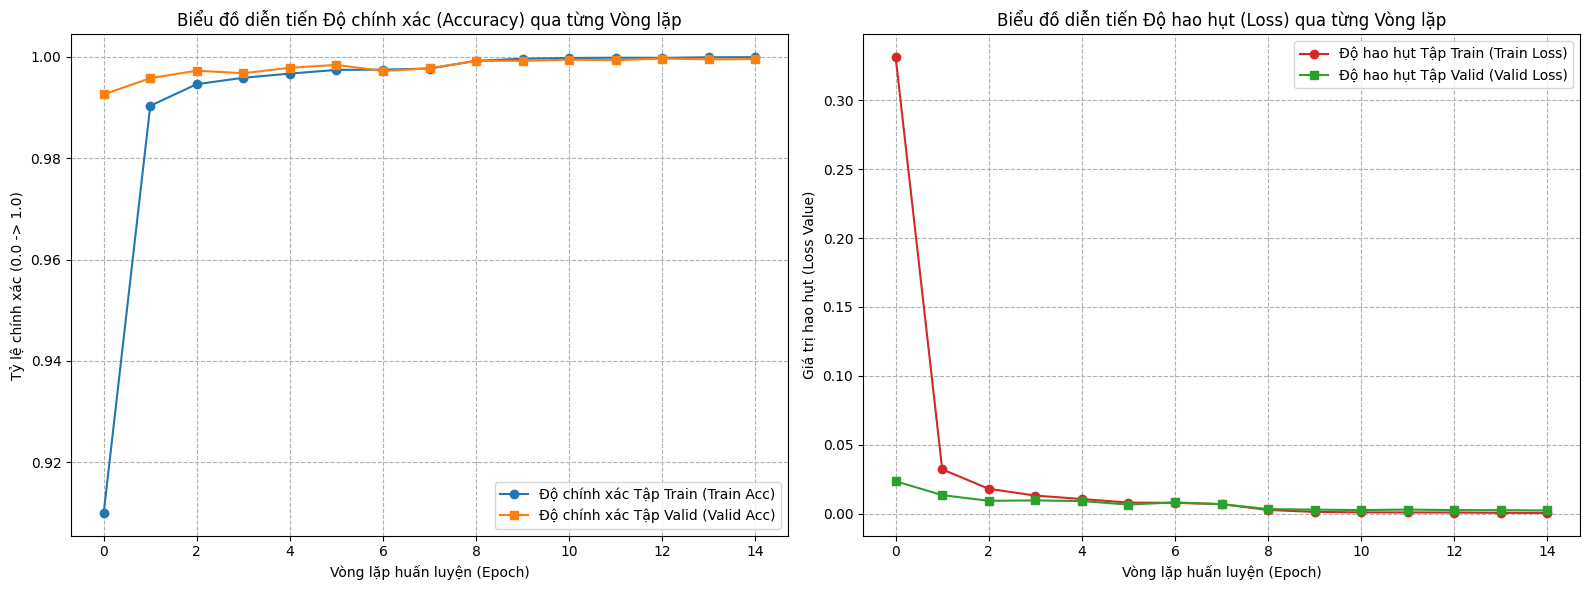


🔍 Đang tiến hành chạy kiểm thử độc lập trên tập dữ liệu TEST...
179/179 ━━━━━━━━━━━━━━━━━━━━ 34s 191ms/step - accuracy: 0.9998 - loss: 0.0011

📊 KẾT QUẢ ĐÁNH GIÁ HỆ THỐNG TRÊN TẬP KIỂM THỬ ĐỘC LẬP:
  - Giá trị Loss trên tập Test: 0.0011
  - Độ chính xác thực tế (Test Accuracy): 99.98%


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# =====================================================================
# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN THƯ MỤC (Sử dụng chính xác cấu trúc dữ liệu của bạn)
# =====================================================================
TRAIN_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VALID_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
TEST_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Khởi tạo Generator giữ nguyên cấu hình rescale=1./255 bạn đã kiểm tra thành công
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("🔄 Đang nạp tập dữ liệu Train...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

print("🔄 Đang nạp tập dữ liệu Valid...")
valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print("🔄 Đang nạp tập dữ liệu Test...")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# =====================================================================
# 2. XÂY DỰNG MÔ HÌNH EFFICIENTNET-B0 VÀ FINE-TUNING
# =====================================================================
def build_plant_model(num_classes=38):
    inputs = layers.Input(shape=(224, 224, 3))

    # LƯU Ý KỸ THUẬT: Kiến trúc EfficientNet-B0 gốc yêu cầu dải pixel [0, 255].
    # Vì generator của bạn đã scale về [0, 1], ta dùng tầng Lambda này để nhân ngược lại 255.0
    # Giúp mô hình tận dụng trọn vẹn sức mạnh của bộ trọng số pre-trained ImageNet.
    x = layers.Lambda(lambda img: img * 255.0)(inputs)

    # Khởi tạo mạng nền tảng EfficientNetB0
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_tensor=x
    )

    # Mở đóng băng (Unfreeze) để cho phép tinh chỉnh toàn bộ mạng (Fine-tuning)
    # Phương pháp này tối ưu nhất cho tập dữ liệu lớn (>70k ảnh) của bạn
    base_model.trainable = True

    # Thiết kế các lớp phân loại phía trên (Top Layers) chống Overfitting
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)  # Màng lọc Dropout 30% giúp kiểm soát hiện tượng overfitting

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_plant_model(num_classes=38)

# Biên dịch mô hình với tốc độ học (Learning Rate) thấp để tránh làm hỏng cấu trúc ImageNet
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =====================================================================
# 3. THIẾT LẬP CÁC BỘ GIÁM SÁT TỰ ĐỘNG (CALLBACKS)
# =====================================================================
checkpoint_path = "best_plant_disease_model.keras"

# Tự động lưu lại Model có độ chính xác trên tập Valid tốt nhất
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Tự động dừng cuộc chơi nếu sau 4 epoch liên tiếp val_loss không giảm thêm (Chống lãng phí tài nguyên)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Tự động giảm tốc độ học (Learning Rate) đi 5 lần nếu mô hình rơi vào trạng thái bão hòa (đi ngang)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [model_checkpoint, early_stopping, reduce_lr]

# =====================================================================
# 4. TIẾN HÀNH HUẤN LUYỆN (TRAIN MODEL)
# =====================================================================
EPOCHS = 15  # Hệ thống dữ liệu lớn, bạn có thể đặt 10-15; EarlyStopping sẽ tự ngắt khi đạt đỉnh

print("\n🚀 Hệ thống bắt đầu quá trình huấn luyện mô hình...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks_list,
    verbose=1
)

# =====================================================================
# 5. TRỰC QUAN HÓA BIỂU ĐỒ ĐÁNH GIÁ (QUÁ TRÌNH THEO THỜI GIAN)
# =====================================================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(16, 6))

# Biểu đồ diễn tiến Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Độ chính xác Tập Train (Train Acc)', color='#1f77b4', marker='o')
plt.plot(epochs_range, val_acc, label='Độ chính xác Tập Valid (Valid Acc)', color='#ff7f0e', marker='s')
plt.title('Biểu đồ diễn tiến Độ chính xác (Accuracy) qua từng Vòng lặp')
plt.xlabel('Vòng lặp huấn luyện (Epoch)')
plt.ylabel('Tỷ lệ chính xác (0.0 -> 1.0)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--')

# Biểu đồ diễn tiến Độ hao hụt (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Độ hao hụt Tập Train (Train Loss)', color='#d62728', marker='o')
plt.plot(epochs_range, val_loss, label='Độ hao hụt Tập Valid (Valid Loss)', color='#2ca02c', marker='s')
plt.title('Biểu đồ diễn tiến Độ hao hụt (Loss) qua từng Vòng lặp')
plt.xlabel('Vòng lặp huấn luyện (Epoch)')
plt.ylabel('Giá trị hao hụt (Loss Value)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# =====================================================================
# 6. KIỂM THỬ ĐỘC LẬP TRÊN TẬP TEST (ĐÁNH GIÁ CUỐI CÙNG)
# =====================================================================
print("\n🔍 Đang tiến hành chạy kiểm thử độc lập trên tập dữ liệu TEST...")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print("\n" + "="*60)
print("📊 KẾT QUẢ ĐÁNH GIÁ HỆ THỐNG TRÊN TẬP KIỂM THỬ ĐỘC LẬP:")
print(f"  - Giá trị Loss trên tập Test: {test_loss:.4f}")
print(f"  - Độ chính xác thực tế (Test Accuracy): {test_acc * 100:.2f}%")
print("="*60)

DATASET2

In [ ]:
import time
import os

start_time = time.time()

zip_name = "test.zip"
folder_path = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

print("🚀 Bắt đầu nén thư mục...")
print(f"📁 Folder: {folder_path}")
print(f"📦 File zip: {zip_name}")

# chạy lệnh zip
os.system(f"zip -r -q {zip_name} '{folder_path}'")

end_time = time.time()

# kiểm tra file có tồn tại không
if os.path.exists(zip_name):
    size = os.path.getsize(zip_name) / (1024 * 1024)  # MB

    print("\n✅ NÉN THÀNH CÔNG!")
    print(f"📦 File: {zip_name}")
    print(f"📏 Dung lượng: {size:.2f} MB")
    print(f"⏱ Thời gian: {end_time - start_time:.2f} giây")
else:
    print("\n❌ Nén thất bại! Kiểm tra lại đường dẫn.")

🚀 Bắt đầu nén thư mục...
📁 Folder: /content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test
📦 File zip: test.zip

✅ NÉN THÀNH CÔNG!
📦 File: test.zip
📏 Dung lượng: 0.01 MB
⏱ Thời gian: 0.01 giây


In [ ]:
import os

print(os.path.exists("/content/test.zip"))

True


In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:18<00:00, 117MB/s]



In [ ]:
!unzip -q plantvillage-dataset.zip -d /content/plantdisease_data2/

In [ ]:
import os
import random
import shutil

# ===== PATH =====
source_root = "/content/plantdisease_data2/plantvillage dataset/color"
target_root = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

# ===== số ảnh mỗi class =====
N = 150

# ===== lấy danh sách class =====
classes = os.listdir(source_root)

print(f"Tìm thấy {len(classes)} classes")

# ===== loop từng class =====
for cls in classes:
    src_class_path = os.path.join(source_root, cls)
    tgt_class_path = os.path.join(target_root, cls)

    # bỏ qua nếu không phải folder
    if not os.path.isdir(src_class_path):
        continue

    # tạo folder test nếu chưa có
    os.makedirs(tgt_class_path, exist_ok=True)

    # lấy tất cả ảnh
    images = os.listdir(src_class_path)

    # random 150 ảnh (nếu ít hơn 150 thì lấy hết)
    selected = random.sample(images, min(N, len(images)))

    # copy sang test
    for img in selected:
        src_img = os.path.join(src_class_path, img)
        dst_img = os.path.join(tgt_class_path, img)

        shutil.copy2(src_img, dst_img)

    print(f"{cls}: copied {len(selected)} images")

print("DONE!")

Tìm thấy 38 classes
Apple___Black_rot: copied 150 images
Apple___healthy: copied 150 images
Peach___Bacterial_spot: copied 150 images
Tomato___Tomato_mosaic_virus: copied 150 images
Tomato___Late_blight: copied 150 images
Tomato___Bacterial_spot: copied 150 images
Cherry_(including_sour)___healthy: copied 150 images
Squash___Powdery_mildew: copied 150 images
Tomato___Target_Spot: copied 150 images
Corn_(maize)___Common_rust_: copied 150 images
Grape___healthy: copied 150 images
Raspberry___healthy: copied 150 images
Potato___Early_blight: copied 150 images
Grape___Black_rot: copied 150 images
Tomato___Spider_mites Two-spotted_spider_mite: copied 150 images
Tomato___healthy: copied 150 images
Cherry_(including_sour)___Powdery_mildew: copied 150 images
Potato___healthy: copied 150 images
Corn_(maize)___Northern_Leaf_Blight: copied 150 images
Tomato___Early_blight: copied 150 images
Peach___healthy: copied 150 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): copied 150 images
Orange___H

Danh sách class:
0: Apple___Black_rot
1: Apple___healthy
2: Peach___Bacterial_spot
3: Tomato___Tomato_mosaic_virus
4: Tomato___Late_blight
5: Tomato___Bacterial_spot
6: Cherry_(including_sour)___healthy
7: Squash___Powdery_mildew
8: Tomato___Target_Spot
9: Corn_(maize)___Common_rust_
10: Grape___healthy
11: Raspberry___healthy
12: Potato___Early_blight
13: Grape___Black_rot
14: Tomato___Spider_mites Two-spotted_spider_mite
15: Tomato___healthy
16: Cherry_(including_sour)___Powdery_mildew
17: Potato___healthy
18: Corn_(maize)___Northern_Leaf_Blight
19: Tomato___Early_blight
20: Peach___healthy
21: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
22: Orange___Haunglongbing_(Citrus_greening)
23: Tomato___Leaf_Mold
24: Strawberry___Leaf_scorch
25: Potato___Late_blight
26: Grape___Esca_(Black_Measles)
27: Pepper,_bell___healthy
28: Apple___Apple_scab
29: Blueberry___healthy
30: Apple___Cedar_apple_rust
31: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
32: Strawberry___healthy
33: Tomato___Se

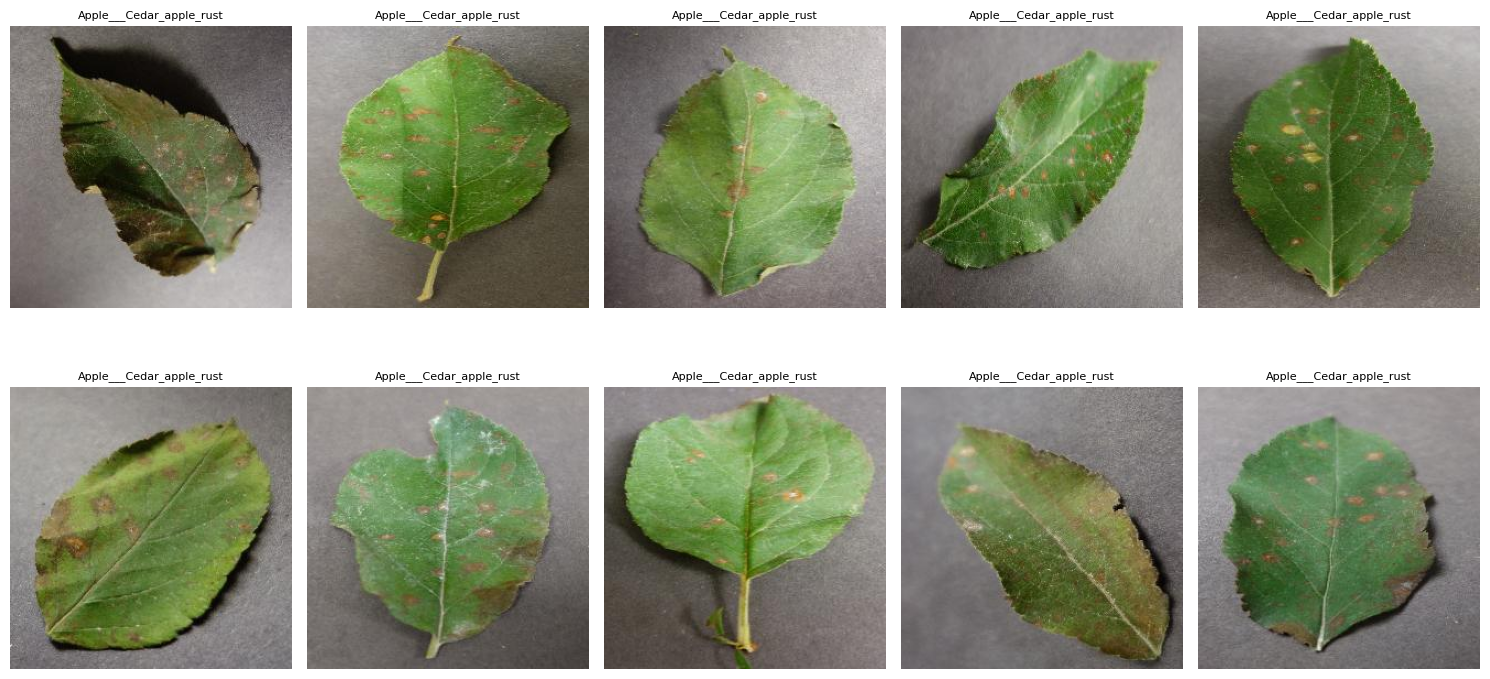

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ===== PATH TEST =====
test_root = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test"

# ===== HIỂN THỊ DANH SÁCH CLASS =====
classes = [c for c in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, c))]

print("Danh sách class:")
for i, c in enumerate(classes):
    print(f"{i}: {c}")

# ===== CHỌN CLASS =====
idx = int(input("\nNhập số thứ tự class muốn xem: "))
selected_class = classes[idx]

print(f"\nBạn chọn: {selected_class}")

# ===== LẤY ẢNH TRONG CLASS =====
class_path = os.path.join(test_root, selected_class)
images = os.listdir(class_path)

# kiểm tra có đủ ảnh không
if len(images) == 0:
    print("Class này chưa có ảnh!")
else:
    sample_imgs = random.sample(images, min(10, len(images)))

    # ===== HIỂN THỊ =====
    plt.figure(figsize=(15, 8))

    for i, img_name in enumerate(sample_imgs):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(selected_class, fontsize=8)

    plt.tight_layout()
    plt.show()